In [1]:

# RECRUITER SIDE - TRANSFORMER VERSION WITH VISUALIZATION


import re
import PyPDF2
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading Transformer Model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model Loaded!\n")


# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# Extract PDF
def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, 'rb') as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + " "
    return text




Loading Transformer Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Loaded!



Processing resumes...

=====  CANDIDATE RANKING =====

                     Resume File  Match Score (%)           Status
2              sample_resume.pdf        54.810001  Not Shortlisted
0  data-scientist-1559725114.pdf        31.830000  Not Shortlisted
1                       IOS1.pdf        29.540001  Not Shortlisted


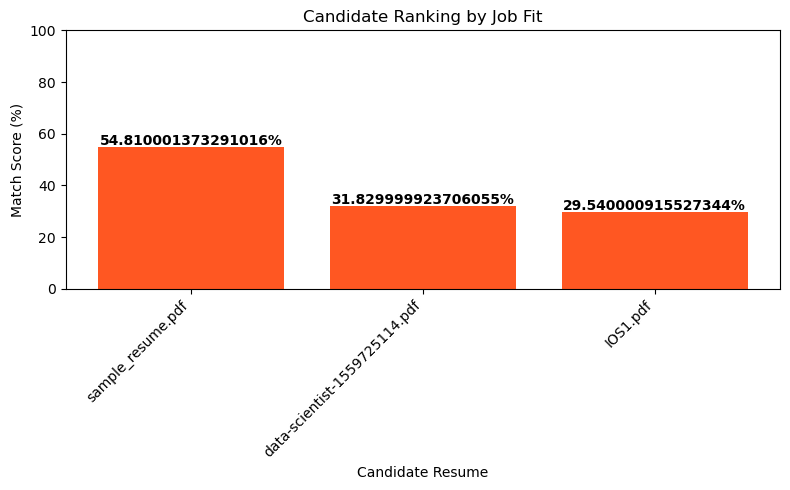

In [2]:
# Main Recruiter Function
def recruiter_side(job_description, resume_list):

    print("Processing resumes...\n")

    job_clean = clean_text(job_description)

    resume_texts = []
    valid_files = []

    for resume in resume_list:
        try:
            text = extract_text_from_pdf(resume)
            resume_texts.append(clean_text(text))
            valid_files.append(resume)
        except:
            print(f"Error reading {resume}")

    if not resume_texts:
        print("No valid resumes to process.")
        return

    # Encode once
    job_embedding = model.encode([job_clean])
    resume_embeddings = model.encode(resume_texts)

    similarities = cosine_similarity(job_embedding, resume_embeddings)[0] * 100

    results = []
    for file, score in zip(valid_files, similarities):
        results.append({
            "Resume File": file,
            "Match Score (%)": round(score, 2),
            "Status": "Shortlisted" if score >= 70 else "Not Shortlisted"
        })

    result_df = pd.DataFrame(results).sort_values(by="Match Score (%)", ascending=False)

    print("=====  CANDIDATE RANKING =====\n")
    print(result_df)

    # ----------------------------
    # Bar Chart: Candidate Ranking
    # ----------------------------
    plt.figure(figsize=(8,5))
    bar_colors = ['#4CAF50' if s >= 70 else '#FF5722' for s in result_df['Match Score (%)']]
    plt.bar(result_df['Resume File'], result_df['Match Score (%)'], color=bar_colors)
    plt.xlabel("Candidate Resume")
    plt.ylabel("Match Score (%)")
    plt.title("Candidate Ranking by Job Fit")
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 100)

    for i, score in enumerate(result_df['Match Score (%)']):
        plt.text(i, score + 1, f"{score}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ----------------------------
    

# ===== RUN =====
if __name__ == "__main__":

    job_description = """
    Looking for Python developer with experience in
    machine learning, deep learning, NLP,
    pandas, numpy, SQL and model deployment.
    """

    resume_files = [
        "data-scientist-1559725114.pdf",
        "IOS1.pdf",
        "sample_resume.pdf"
    ]

    recruiter_side(job_description, resume_files)